# Transformers, what can they do?

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [3]:
!pip install datasets evaluate transformers[sentencepiece]

## Image and Audio Pipeline

In [14]:
from google.colab import files

def upload_files():
    uploaded = files.upload()  # Opens a file picker in the browser
    for filename in uploaded.keys():
        print(f"Uploaded file: {filename}")
    return uploaded


In [4]:
from transformers import pipeline

## Image Classification

In [5]:
image_classifier = pipeline(
    task="image-classification", model="google/vit-base-patch16-224"
)
result = image_classifier(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
)
print(result)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cuda:0


[{'label': 'lynx, catamount', 'score': 0.43350017070770264}, {'label': 'cougar, puma, catamount, mountain lion, painter, panther, Felis concolor', 'score': 0.03479619696736336}, {'label': 'snow leopard, ounce, Panthera uncia', 'score': 0.03240185230970383}, {'label': 'Egyptian cat', 'score': 0.023944752290844917}, {'label': 'tiger cat', 'score': 0.022889167070388794}]


In [15]:
upload_files = upload_files()

Saving 7400_IC_Testor.png to 7400_IC_Testor (2).png
Uploaded file: 7400_IC_Testor (2).png


In [9]:
from PIL import Image
import io

In [16]:
# Load the image
image_path = list(upload_files.keys())[0]
image = Image.open(io.BytesIO(upload_files[image_path]))

In [22]:
import matplotlib.pyplot as plt

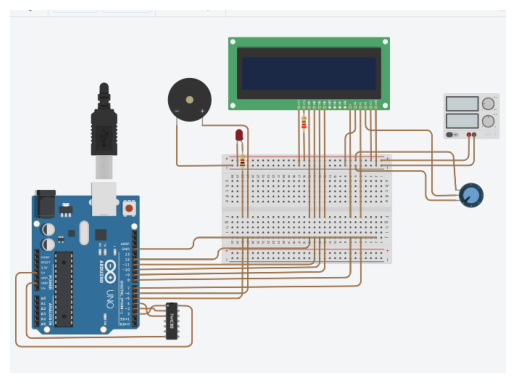

In [23]:
plt.imshow(image)
plt.axis('off')
plt.show()

In [17]:
result2 = image_classifier(
    image
)

In [18]:
print(result2)

[{'label': 'modem', 'score': 0.42776522040367126}, {'label': 'oscilloscope, scope, cathode-ray oscilloscope, CRO', 'score': 0.22082746028900146}, {'label': 'radio, wireless', 'score': 0.0897684246301651}, {'label': 'switch, electric switch, electrical switch', 'score': 0.08206232637166977}, {'label': 'joystick', 'score': 0.04724574834108353}]


In [19]:
transcriber = pipeline(
    task="automatic-speech-recognition", model="openai/whisper-large-v3"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

Device set to use cuda:0


In [20]:
result = transcriber(
    "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac"
)
print(result)

/usr/local/lib/python3.11/dist-packages/transformers/models/whisper/generation_whisper.py:573: FutureWarning: The input name `inputs` is deprecated. Please make sure to use `input_features` instead.
  warnings.warn(
Due to a bug fix in https://github.com/huggingface/transformers/pull/28687 transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English.This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`.


{'text': ' I have a dream that one day this nation will rise up and live out the true meaning of its creed.'}
